In [1]:
import numpy as np 
import pandas as pd

In [2]:
data=pd.read_csv('final_all.csv')
data.head()

,Year,Month,Day,f10,s10,M10,Y10,plage,corrected_p,total SSA,SSN
0,1905,1,1,0.0,0.0,0.0,0.0,0.0,0.0,440.0,50
1,1905,1,2,0.0,0.0,0.0,0.0,0.0,0.0,440.0,33
2,1905,1,2,0.0,0.0,0.0,0.0,0.0,0.0,440.0,33
3,1905,1,3,0.0,0.0,0.0,0.0,0.0,0.0,365.0,17
4,1905,1,4,0.0,0.0,0.0,0.0,0.0,0.0,289.0,23


In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


# Create datetime column
data['date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])
data = data.sort_values('date')

# Step 2: Define features and target
features = ['SSN', 'total SSA', 'plage']
target = 'f10'

# Drop any missing values in `f10` if present
data = data.dropna(subset=[target])

# # Step 3: Normalize the features and target
# scaler_x = MinMaxScaler()
# scaler_y = MinMaxScaler()
# # from sklearn.preprocessing import StandardScaler

# Step 3: Normalize the features and target using Z-score normalization
scaler_x = StandardScaler()
scaler_y = StandardScaler()
# Split data for training, testing and prediction (best in town)
df_train = data[(data['Year'] > 2001)]
df_test = data[(data['Year'] > 1996) & (data['Year'] < 2002)]
df_predict = data[data['Year'] < 1997]

# # Split data for training, testing and prediction (before 1996)
# df_train = data[(data['Year'] > 1996) & (data['Year'] < 2020)]
# df_test = data[(data['Year'] > 2019)]
# df_predict = data[data['Year'] < 1997]

# # Y10 data range
# df_train = data[(data['Year'] > 2001)]
# df_test = data[(data['Year'] > 1996) & (data['Year'] < 2002)]
# df_predict = data[data['Year'] < 1997]

# Create mask for values > 180
mask = df_test['f10'] > 300

# Print count of such values
count = mask.sum()
print(f"Count of values > 180: {count}")
# Replace with average of previous and next
# Safe replacement using position-based indexing
for idx in df_test[mask].index:
    pos = df_test.index.get_loc(idx)
    if 0 < pos < len(df_test) - 1:
        prev_val = df_test.iloc[pos - 1]['f10']
        next_val = df_test.iloc[pos + 1]['f10']
        if pd.notna(prev_val) and pd.notna(next_val):
            old_val = df_test.iloc[pos]['f10']
            new_val = (prev_val + next_val) / 2
            df_test.iat[pos, df_test.columns.get_loc('f10')] = new_val
            print(f"Replaced value {old_val} at index {idx} with average of {prev_val} and {next_val} → {new_val}")

print("\nUpdated DataFrame:")
print(df_test)

Count of values > 180: 0

Updated DataFrame:
       Year  Month  Day    f10    s10    M10    Y10   plage  corrected_p  \
33604  1997      1    1   72.4   74.0   65.4   61.9  0.0059       0.0067   
33605  1997      1    2   72.1   73.8   66.9   63.4  0.0049       0.0043   
33606  1997      1    3   73.3   75.0   70.1   64.9  0.0074       0.0057   
33607  1997      1    4   73.8   76.3   71.6   65.5  0.0055       0.0047   
33608  1997      1    5   74.4   77.6   72.4   66.7  0.0068       0.0052   
...     ...    ...  ...    ...    ...    ...    ...     ...          ...   
35425  2001     12   27  274.6  229.0  225.8  195.6  0.0515       0.0414   
35426  2001     12   28  263.3  231.6  219.5  202.6  0.0514       0.0408   
35427  2001     12   29  264.4  230.0  220.3  190.2  0.0535       0.0387   
35428  2001     12   30  246.6  228.5  227.3  183.6  0.0555       0.0398   
35429  2001     12   31  245.6  227.6  232.0  178.1  0.0518       0.0401   

       total SSA  SSN       date  
33604  

In [4]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dropout

# # Scale features
# X_train_scaled = scaler_x.fit_transform(df_train[features])
# y_train_scaled = scaler_y.fit_transform(df_train[[target]])
# X_test_scaled = scaler_x.transform(df_test[features])
# X_predict_scaled = scaler_x.transform(df_predict[features])
# Fit and transform training data
X_train_scaled = scaler_x.fit_transform(df_train[features])
y_train_scaled = scaler_y.fit_transform(df_train[[target]])

# Transform test and prediction input data using same training scalers
X_test_scaled = scaler_x.transform(df_test[features])
X_predict_scaled = scaler_x.transform(df_predict[features])

# Step 4: Prepare sequences for LSTM
def create_sequences(X, y=None, seq_len=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        if y is not None:
            ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys) if y is not None else np.array(Xs)

SEQ_LEN = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len=SEQ_LEN)
X_test_seq = create_sequences(X_test_scaled, seq_len=SEQ_LEN)
X_pred_seq = create_sequences(X_predict_scaled, seq_len=SEQ_LEN)

# Step 5: Define and train LSTM model
model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, len(features)), return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1)
])
# model = Sequential([
#     LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, len(features))),  # new LSTM layer
#     LSTM(256, return_sequences=False),  # original LSTM layer
#     Dense(64, activation='relu'),       # original Dense layer
#     Dense(31, activation='relu'),       # new Dense layer
#     Dense(1)                             # output layer
# ])
# model.compile(optimizer='adam', loss=weighted_mse)

model.compile(optimizer='adam', loss='mse')
model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32,
          validation_split=0.3,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
          verbose=1)

# testing the model
F10_test_scaled = model.predict(X_test_seq)
# F10_test = scaler_y.inverse_transform(F10_test_scaled)
F10_test = scaler_y.inverse_transform(F10_test_scaled)

# Step 7: Create output DataFrame
test_dates = df_test['date'].iloc[SEQ_LEN:].reset_index(drop=True)
df_test_pred = pd.DataFrame({
    'date': test_dates,
    'predicted_f10': F10_test.flatten()
})
print(df_test_pred.head())

C:\Users\pbelbase\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - loss: 0.1189 - val_loss: 0.1765
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0512 - val_loss: 0.1420
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 0.0459 - val_loss: 0.1137
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - loss: 0.0452 - val_loss: 0.1132
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 0.0476 - val_loss: 0.1111
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - loss: 0.0419 - val_loss: 0.1534
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - loss: 0.0399 - val_loss: 0.1336
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - loss: 0.0433 - val_loss: 0.1225
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0414 - val_loss: 0.1243
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 0.0393 - val_loss: 0.1176


C:\Users\pbelbase\AppData\Local\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 30, 3))', 'Tensor(shape=(32, 30, 3))')
  warnings.warn(msg)


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

C:\Users\pbelbase\AppData\Local\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 30, 3))', 'Tensor(shape=(None, 30, 3))')
  warnings.warn(msg)


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
        date  predicted_f10
0 1997-01-31      73.200943
1 1997-02-01      72.508560
2 1997-02-02      72.743530
3 1997-02-03      76.070328
4 1997-02-04      79.704842


In [5]:
df_test['date'] = pd.to_datetime(df_test[['Year', 'Month', 'Day']])
cutoff = pd.Timestamp('1997-01-30')
df_test_sort=df_test[(df_test['date'] > cutoff)]
df_test_sort.shape

C:\Users\pbelbase\AppData\Local\Temp\2\ipykernel_31944\3567514928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['date'] = pd.to_datetime(df_test[['Year', 'Month', 'Day']])


(1796, 12)

In [6]:
from sklearn.metrics import mean_squared_error
y_test= df_test_sort[[target]]
y_pred_test=df_test_pred[['predicted_f10']]
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'Test RMSE: {test_rmse:.4f}')

Test RMSE: 15.4048


In [7]:
df_test_pred

,date,predicted_f10
0,1997-01-31,73.200943
1,1997-02-01,72.508560
2,1997-02-02,72.743530
3,1997-02-03,76.070328
4,1997-02-04,79.704842
...,...,...
1791,2001-12-27,247.559448
1792,2001-12-28,221.888870
1793,2001-12-29,203.795227
1794,2001-12-30,191.822800


In [8]:
# Step 6: Predict F10 for 1946–1995
f10_pred_scaled = model.predict(X_pred_seq)
f10_pred = scaler_y.inverse_transform(f10_pred_scaled)

# Step 7: Create output DataFrame
pred_dates = df_predict['date'].iloc[SEQ_LEN:].reset_index(drop=True)
df_result = pd.DataFrame({
    'date': pred_dates,
    'predicted_f10': f10_pred.flatten()
})

print(df_result.head())

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step
        date  predicted_f10
0 1905-01-30     114.333572
1 1905-01-31     123.782387
2 1905-02-01     131.043884
3 1905-02-02     132.400574
4 1905-02-03     147.580505


In [19]:
# model.save("F10_final.h5")

C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_21236\4158319766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['YearMonth'] = df_test['Year'] + (df_test['Month'] - 1) / 12
C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_21236\4158319766.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['YearMonth'] = df_train['Year'] + (df_train['Month'] - 1) / 12
C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_21236\4158319766.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy 

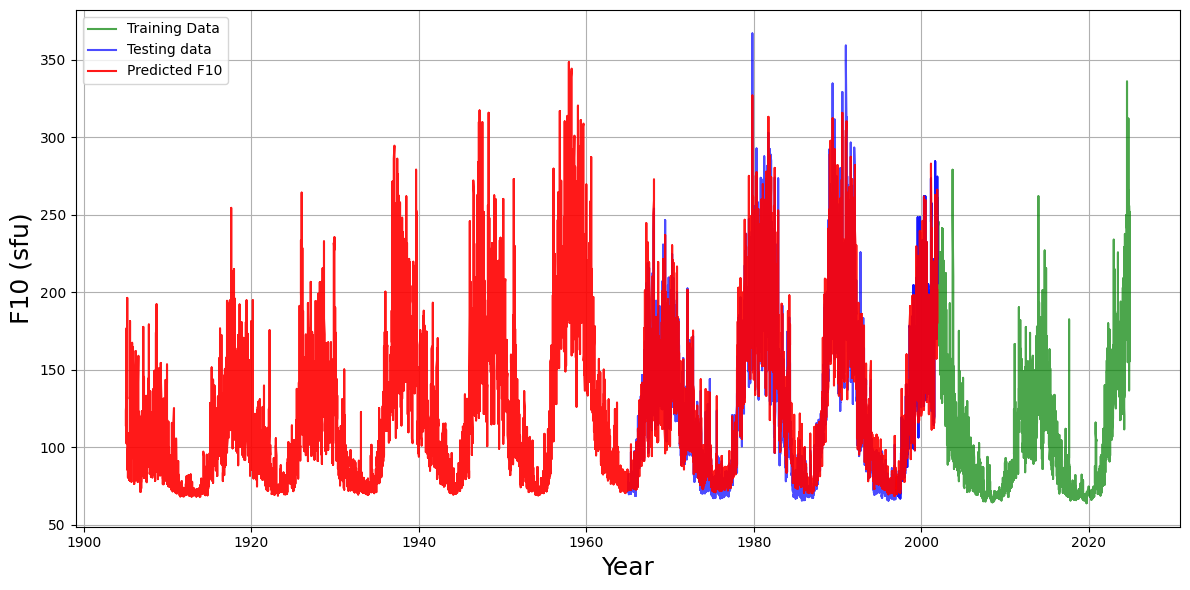

In [10]:
import matplotlib.pyplot as plt
# Convert Year and Month into a continuous variable
df_result['YearMonth'] = df_result['date'].dt.year + (df_result['date'].dt.month - 1) / 12
df_test['YearMonth'] = df_test['Year'] + (df_test['Month'] - 1) / 12
df_train['YearMonth'] = df_train['Year'] + (df_train['Month'] - 1) / 12
df_test_pred['YearMonth'] = df_test_pred['date'].dt.year + (df_test_pred['date'].dt.month - 1) / 12
df_predict['YearMonth'] = df_predict['Year'] + (df_predict['Month'] - 1) / 12
df_predict_filtered = df_predict[
    (df_predict['YearMonth'] >= 1965) & 
    (df_predict['YearMonth'] <= 1997)
]

# Scatter plot for training data
plt.figure(figsize=(12, 6))

plt.plot(
    df_train['YearMonth'], 
    df_train['f10'], 
    color='green', 
    label='Training Data', 
    alpha=0.7
)

# Scatter plot for testing data
plt.plot(
    df_test['YearMonth'], 
    df_test['f10'], 
    color='blue', 
    label='Testing data', 
    alpha=0.7
)


# Scatter plot for testing data
plt.plot(
    df_test['YearMonth'], 
    df_test['f10'], 
    color='blue',  
    alpha=0.7
)
plt.plot(
    df_predict_filtered['YearMonth'], 
    df_predict_filtered['f10'], 
    color='blue',  
    alpha=0.7
)
plt.plot(
    df_result['YearMonth'], 
    df_result['predicted_f10'], 
    color='red', 
    label='Predicted F10', 
    alpha=0.9
)
# Scatter plot for testing data
plt.plot(
    df_test_pred['YearMonth'], 
    df_test_pred['predicted_f10'], 
    color='red',  
    alpha=0.9
)

# plt.plot(
#     datar['YearMonth'], 
#     datar['predicted_f10'], 
#     color='green', 
#     label='past prediction', 
#     alpha=0.7
# )





plt.xlabel('Year', fontsize=18)
plt.ylabel('F10 (sfu)', fontsize=18)
# plt.title('prediction of F10 using all three variables')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('F10_all_LSTM.png', dpi=300)
# Show the plot
plt.show()

In [12]:
# data_pred = df_result[(df_result['date'].dt.year > 1964) & (df_result['date'].dt.year < 1997)]
# data_pred

C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_17332\4184684076.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['YearMonth'] = df_test['Year'] + (df_test['Month'] - 1) / 12
C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_17332\4184684076.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_sort['date'] = pd.to_datetime(df_test_sort['date'])
C:\Users\pbelbase\AppData\Local\Temp\1\ipykernel_17332\4184684076.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping column

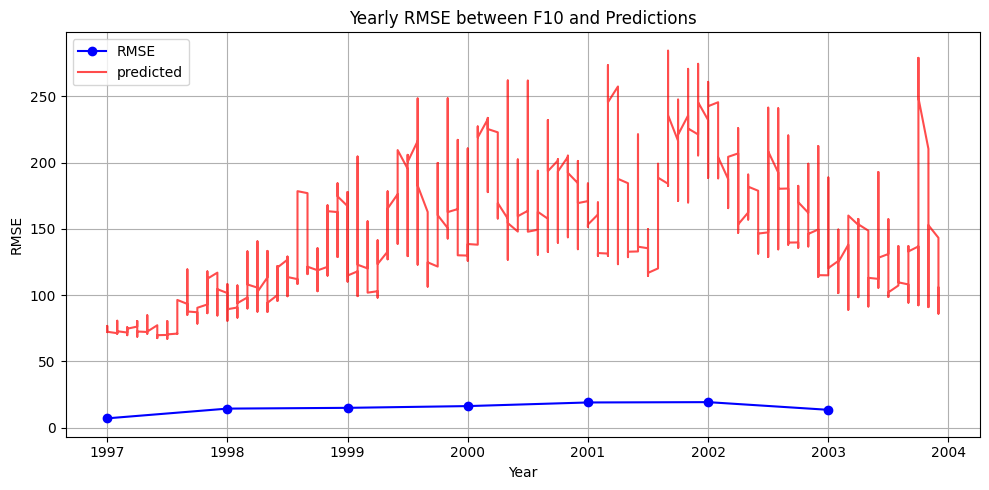

In [117]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
df_test['YearMonth'] = df_test['Year'] + (df_test['Month'] - 1) / 12
# ------------------------------
# Ensure date is datetime type
df_test_sort['date'] = pd.to_datetime(df_test_sort['date'])
df_test_pred['date'] = pd.to_datetime(df_test_pred['date'])


df_merged = pd.merge(df_test_sort, df_test_pred, on='date', how='inner')


df_merged['Year'] = df_merged['date'].dt.year


rmsepred_per_year = df_merged.groupby("Year").apply(
    lambda x: np.sqrt(mean_squared_error(x["f10"], x["predicted_F10"]))
)

# ------------------------------
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(rmsepred_per_year.index, rmsepred_per_year.values,
         marker='o', linestyle='-', color='b', label='RMSE')

# Scatter plot for testing data
plt.plot(
    df_test['YearMonth'], 
    df_test['f10'], 
    color='red', 
    label='predicted', 
    alpha=0.7
)
plt.xlabel("Year")
plt.ylabel("RMSE")
plt.title("Yearly RMSE between F10 and Predictions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
df_predict

,Year,Month,Day,f10,s10,M10,Y10,plage,corrected_p,total SSA,SSN,date,YearMonth
0,1905,1,1,0.0,0.0,0.0,0.0,0.0000,0.0000,440.00,50,1905-01-01,1905.000000
1,1905,1,2,0.0,0.0,0.0,0.0,0.0000,0.0000,440.00,33,1905-01-02,1905.000000
2,1905,1,2,0.0,0.0,0.0,0.0,0.0000,0.0000,440.00,33,1905-01-02,1905.000000
3,1905,1,3,0.0,0.0,0.0,0.0,0.0000,0.0000,365.00,17,1905-01-03,1905.000000
4,1905,1,4,0.0,0.0,0.0,0.0,0.0000,0.0000,289.00,23,1905-01-04,1905.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33599,1996,12,27,72.2,0.0,0.0,0.0,0.0088,0.0089,11.76,0,1996-12-27,1996.916667
33600,1996,12,28,71.8,0.0,0.0,0.0,0.0088,0.0105,0.00,0,1996-12-28,1996.916667
33601,1996,12,29,71.4,0.0,0.0,0.0,0.0063,0.0064,0.00,0,1996-12-29,1996.916667
33602,1996,12,30,70.1,0.0,0.0,0.0,0.0053,0.0049,0.00,0,1996-12-30,1996.916667


C:\Users\pbelbase\AppData\Local\Temp\2\ipykernel_30220\3514875858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['YearMonth'] = df_predict['Year'] + (df_predict['Month'] - 1) / 12
C:\Users\pbelbase\AppData\Local\Temp\2\ipykernel_30220\3514875858.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_filtered['date'] = pd.to_datetime(df_result_filtered['date'])
C:\Users\pbelbase\AppData\Local\Temp\2\ipykernel_30220\3514875858.py:19: SettingWithCopyWarning: 
A value is trying to be set

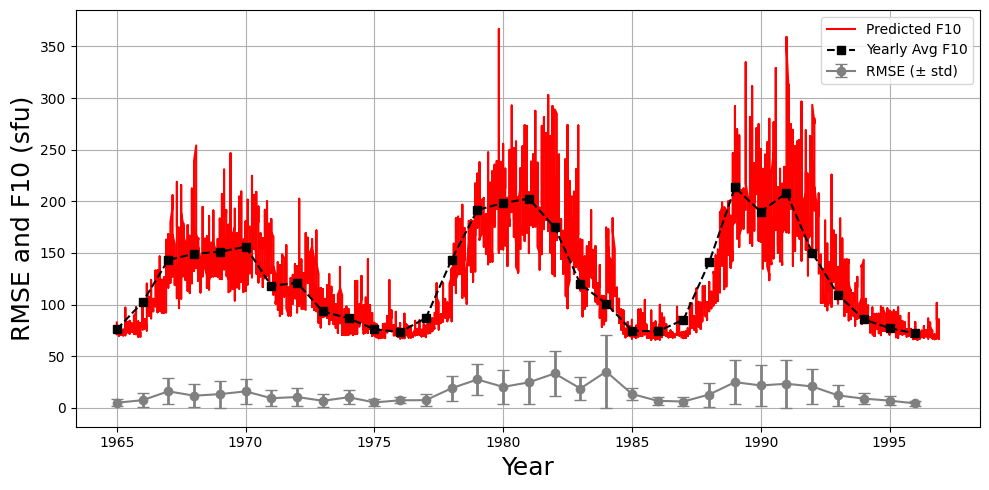

In [57]:
df_result['YearMonth'] = df_result['date'].dt.year + (df_result['date'].dt.month - 1) / 12
df_predict['YearMonth'] = df_predict['Year'] + (df_predict['Month'] - 1) / 12
df_predict_filtered = df_predict[
    (df_predict['YearMonth'] >= 1965) & 
    (df_predict['YearMonth'] <= 1997)
]
df_result_filtered = df_result[
    (df_result['YearMonth'] >= 1965) & 
    (df_result['YearMonth'] <= 1997)
]
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Ensure 'date' is datetime
df_result_filtered['date'] = pd.to_datetime(df_result_filtered['date'])
df_predict_filtered['date'] = pd.to_datetime(df_predict_filtered['date'])

# Merge predictions and true values
df_merged = pd.merge(df_result_filtered, df_predict_filtered, on='date', how='inner')
df_merged['Year'] = df_merged['date'].dt.year

# Compute RMSE per year
rmsepred_per_year = df_merged.groupby("Year").apply(
    lambda x: np.sqrt(mean_squared_error(x["f10"], x["predicted_f10"]))
)

# Compute standard deviation of errors (for error bars)
rmse_std_per_year = df_merged.groupby("Year").apply(
    lambda x: np.std(x["f10"] - x["predicted_f10"])
)

# Compute average F10 per year
avg_f10_per_year = df_merged.groupby("Year")["f10"].mean()

# Plotting
plt.figure(figsize=(10, 5))
# Optional: scatter predicted F10 values
if 'YearMonth' in df_predict_filtered.columns:
    plt.plot(
        df_predict_filtered['YearMonth'], 
        df_predict_filtered['f10'], 
        color='red', 
        label='Predicted F10', 
        alpha=1
    )

# RMSE with error bars (std of errors)
plt.errorbar(
    rmsepred_per_year.index,
    rmsepred_per_year.values,
    yerr=rmse_std_per_year.values,
    fmt='o-', color='grey', ecolor='grey', elinewidth=2, capsize=4,
    label='RMSE (± std)'
)

# Plot average F10
plt.plot(
    avg_f10_per_year.index,
    avg_f10_per_year.values,
    marker='s', linestyle='--', color='black', label='Yearly Avg F10'
)



plt.xlabel("Year", fontsize=18)
plt.ylabel("RMSE and F10 (sfu)", fontsize=18)
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('RMSE_f10_bars.png')
plt.show()